In [ ]:
!pip install pyarrow 
!pip install matplotlib seaborn
!pip install pandas geopandas geopy

In [1]:
import pandas as pd
import numpy as np


In [2]:
yellow_taxi_jan_2026 = pd.read_parquet(r"D:\projects\data analysis\NYC Taxi Data Analysis\data\raw_data\yellow_tripdata_2026-01.parquet")

In [5]:
yellow_taxi_jan_2026.sample(n = 50000).to_csv("yellow_tripdata_2026-01.csv", index=False)

In [3]:
yellow_taxi_jan_2026.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee',
       'cbd_congestion_fee'],
      dtype='str')

# Observer the data for `Dirty Data` and `Messy Data` and note down the issue 

In [6]:
yellow_taxi_jan_2026.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee',
       'cbd_congestion_fee'],
      dtype='str')

In [7]:
yellow_taxi_jan_2026.sample(15)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
649446,2,2026-01-09 09:51:03,2026-01-09 10:00:10,1.0,1.43,1.0,N,50,142,1,10.70,0.00,0.5,0.00,0.00,1.0,15.45,2.5,0.00,0.75
2948065,1,2026-01-11 12:39:55,2026-01-11 12:51:03,NaN,2.00,NaN,NaN,236,151,0,10.66,0.00,0.5,1.00,0.00,1.0,16.45,NaN,NaN,0.00
1386823,2,2026-01-16 21:22:21,2026-01-16 21:53:10,1.0,4.63,1.0,N,261,230,1,31.00,1.00,0.5,11.03,0.00,1.0,47.78,2.5,0.00,0.75
149472,2,2026-01-03 05:21:43,2026-01-03 05:46:26,2.0,17.33,1.0,N,230,138,2,64.60,6.00,0.5,0.00,6.94,1.0,82.29,2.5,0.00,0.75
421234,1,2026-01-06 17:36:54,2026-01-06 17:43:19,1.0,1.00,1.0,N,263,237,1,7.20,5.00,0.5,2.75,0.00,1.0,16.45,2.5,0.00,0.00
3696533,2,2026-01-31 15:16:15,2026-01-31 15:31:52,NaN,1.12,NaN,NaN,211,79,0,18.18,0.00,0.5,0.00,0.00,1.0,22.93,NaN,NaN,0.75
1565161,2,2026-01-19 07:50:45,2026-01-19 08:20:22,2.0,17.79,1.0,N,100,138,1,67.40,5.00,0.5,5.00,7.46,1.0,89.61,2.5,0.00,0.75
2391745,2,2026-01-29 14:51:16,2026-01-29 15:07:08,1.0,1.36,1.0,N,43,161,1,14.20,0.00,0.5,2.00,0.00,1.0,20.95,2.5,0.00,0.75
2173207,2,2026-01-26 19:28:28,2026-01-26 19:49:43,2.0,7.83,1.0,N,138,41,1,34.50,7.50,0.5,10.54,7.46,1.0,63.25,0.0,1.75,0.00
1593721,1,2026-01-19 15:33:35,2026-01-19 15:41:26,1.0,1.40,1.0,N,142,50,1,8.60,3.25,0.5,1.00,0.00,1.0,14.35,2.5,0.00,0.75


In [8]:
yellow_taxi_jan_2026.info()

<class 'pandas.DataFrame'>
RangeIndex: 3724889 entries, 0 to 3724888
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee            float64   

In [9]:
yellow_taxi_jan_2026.duplicated().sum()

np.int64(0)

In [10]:
yellow_taxi_jan_2026.isna().sum()

VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count          1088058
trip_distance                  0
RatecodeID               1088058
store_and_fwd_flag       1088058
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge     1088058
Airport_fee              1088058
cbd_congestion_fee             0
dtype: int64

# column wise checking

-- VendorID

In [11]:
yellow_taxi_jan_2026['VendorID'].unique()

array([2, 1, 7, 6], dtype=int32)

<Axes: xlabel='VendorID'>

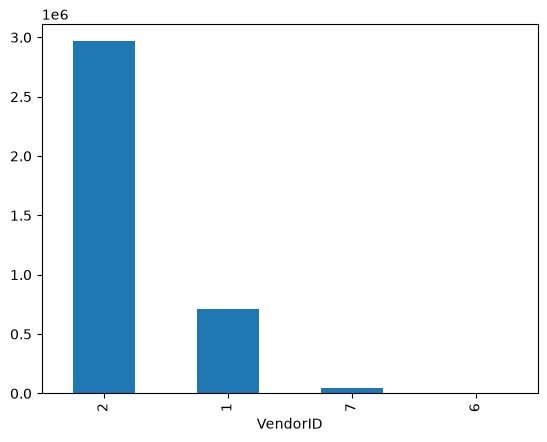

In [12]:
yellow_taxi_jan_2026['VendorID'].value_counts(dropna=False).plot(kind='bar')

-- tpep_pickup_datetime

In [13]:
yellow_taxi_jan_2026[
    ~((yellow_taxi_jan_2026['tpep_pickup_datetime'].dt.year == 2026) &
    (yellow_taxi_jan_2026['tpep_pickup_datetime'].dt.month == 1 ))
]


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
980,2,2025-12-31 23:57:29,2025-12-31 23:57:32,2.0,0.01,2.0,N,132,264,3,-70.0,0.0,-0.5,0.00,0.0,-1.0,-71.50,0.0,0.00,0.00
981,2,2025-12-31 23:57:29,2025-12-31 23:57:32,2.0,0.01,2.0,N,132,264,3,70.0,0.0,0.5,0.00,0.0,1.0,71.50,0.0,0.00,0.00
982,2,2025-12-31 23:58:58,2026-01-01 01:04:39,2.0,40.14,3.0,N,132,1,2,167.2,1.0,0.0,0.00,27.0,1.0,198.70,0.0,1.75,0.75
1404,2,2025-12-31 23:57:54,2026-01-01 00:09:36,1.0,2.00,1.0,N,164,144,1,12.8,1.0,0.5,2.00,0.0,1.0,20.55,2.5,0.00,0.75
2289,2,2025-12-31 23:59:06,2026-01-01 00:16:43,1.0,0.43,1.0,N,163,48,2,14.9,1.0,0.5,0.00,0.0,1.0,20.65,2.5,0.00,0.75
5181,2,2025-12-31 23:58:45,2026-01-01 00:07:12,1.0,1.68,1.0,N,113,4,1,10.7,1.0,0.5,2.00,0.0,1.0,18.45,2.5,0.00,0.75
2635466,2,2026-02-01 00:45:01,2026-02-01 01:03:08,1.0,1.78,1.0,N,79,249,1,15.6,1.0,0.5,5.34,0.0,1.0,26.69,2.5,0.00,0.75


In [14]:
yellow_taxi_jan_2026['tpep_pickup_datetime'].describe()

count                       3724889
mean     2026-01-17 01:44:52.106518
min             2025-12-31 23:57:29
25%             2026-01-09 17:51:59
50%             2026-01-16 21:20:56
75%             2026-01-24 07:25:11
max             2026-02-01 00:45:01
Name: tpep_pickup_datetime, dtype: object

-- tpep_dropoff_datetime

In [15]:
yellow_taxi_jan_2026['tpep_dropoff_datetime'].describe()

count                       3724889
mean     2026-01-17 02:02:03.696138
min             2025-12-31 23:57:32
25%             2026-01-09 18:08:47
50%             2026-01-16 21:36:14
75%             2026-01-24 07:40:22
max             2026-02-01 23:35:31
Name: tpep_dropoff_datetime, dtype: object

-- passenger_count

In [16]:
yellow_taxi_jan_2026['passenger_count'].describe()

count    2.636831e+06
mean     1.256271e+00
std      6.702431e-01
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      9.000000e+00
Name: passenger_count, dtype: float64

In [17]:
(
    yellow_taxi_jan_2026["passenger_count"].notna() &
    (yellow_taxi_jan_2026["passenger_count"] % 1 != 0)
).sum()


np.int64(0)

In [18]:
yellow_taxi_jan_2026[yellow_taxi_jan_2026['passenger_count']==9]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
212630,2,2026-01-03 21:27:58,2026-01-03 21:28:10,9.0,0.0,5.0,N,209,209,1,94.0,0.0,0.5,0.0,0.0,1.0,98.75,2.5,0.0,0.75


In [19]:
(yellow_taxi_jan_2026['passenger_count'] == 0).sum()

np.int64(14787)

<Axes: >

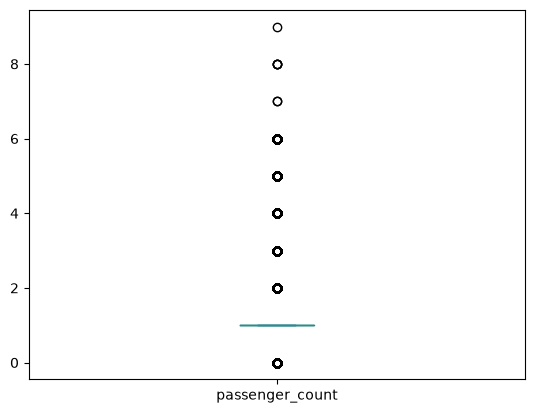

In [20]:
yellow_taxi_jan_2026['passenger_count'].plot(kind='box')

<Axes: ylabel='Frequency'>

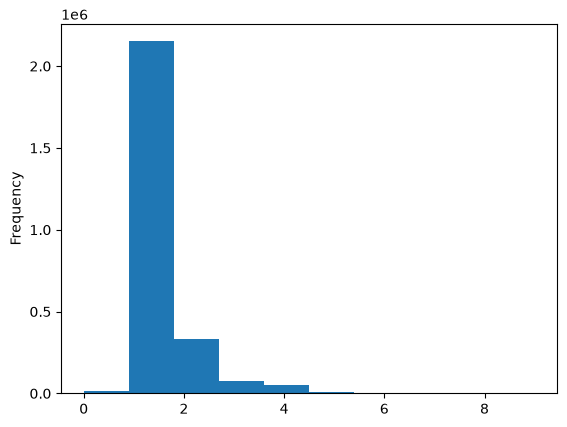

In [21]:
yellow_taxi_jan_2026['passenger_count'].plot(kind='hist')

In [22]:
yellow_taxi_jan_2026[yellow_taxi_jan_2026['passenger_count']>5]['passenger_count'].value_counts()

passenger_count
6.0    4887
8.0       4
7.0       2
9.0       1
Name: count, dtype: int64

-- trip_distance

In [23]:
yellow_taxi_jan_2026['trip_distance'].describe()

count    3.724889e+06
mean     6.455647e+00
std      6.488855e+02
min      0.000000e+00
25%      1.000000e+00
50%      1.810000e+00
75%      3.730000e+00
max      2.690975e+05
Name: trip_distance, dtype: float64

<Axes: >

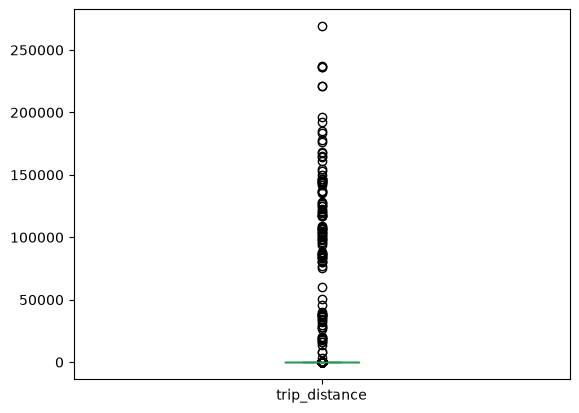

In [24]:
yellow_taxi_jan_2026['trip_distance'].plot(kind='box')

In [25]:
yellow_taxi_jan_2026[yellow_taxi_jan_2026['trip_distance'] > 350]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
77980,2,2026-01-02 10:20:45,2026-01-02 10:36:06,2.0,36610.27,4.0,N,138,170,2,105.27,0.0,0.0,0.00,6.94,0.0,117.21,2.5,1.75,0.75
1263708,2,2026-01-15 18:30:38,2026-01-15 18:40:15,3.0,8301.22,4.0,N,164,68,1,10.00,2.5,0.5,3.45,0.00,1.0,20.70,2.5,0.00,0.75
1500882,2,2026-01-18 09:52:01,2026-01-18 09:58:07,1.0,98773.58,5.0,N,179,146,1,7.10,0.0,0.5,0.00,0.00,1.0,8.60,0.0,0.00,0.00
2663467,2,2026-01-01 11:25:00,2026-01-01 11:34:00,NaN,136722.06,NaN,NaN,4,170,0,10.19,0.0,0.5,0.00,0.00,1.0,15.94,NaN,NaN,0.75
2666504,2,2026-01-01 12:54:00,2026-01-01 13:13:00,NaN,93929.48,NaN,NaN,36,260,0,31.62,0.0,0.5,0.00,0.00,1.0,33.12,NaN,NaN,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3620632,2,2026-01-30 07:53:00,2026-01-30 08:25:00,NaN,142185.56,NaN,NaN,61,231,0,31.28,0.0,0.5,5.40,0.00,1.0,41.43,NaN,NaN,0.75
3625377,2,2026-01-30 09:12:00,2026-01-30 09:28:00,NaN,16338.51,NaN,NaN,79,88,0,35.20,0.0,0.5,0.00,0.00,1.0,39.95,NaN,NaN,0.75
3632367,2,2026-01-30 13:00:00,2026-01-30 13:38:00,NaN,237567.19,NaN,NaN,42,130,0,72.99,0.0,0.5,0.00,7.46,1.0,81.95,NaN,NaN,0.00
3634297,2,2026-01-30 14:18:00,2026-01-30 14:50:00,NaN,34816.24,NaN,NaN,212,220,0,31.68,0.0,0.5,0.00,0.00,1.0,33.18,NaN,NaN,0.00


-- RatecodeID

In [26]:
yellow_taxi_jan_2026['RatecodeID'].describe()

count    2.636831e+06
mean     5.218853e+00
std      1.965370e+01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      9.900000e+01
Name: RatecodeID, dtype: float64

In [27]:
yellow_taxi_jan_2026['RatecodeID'].unique()

array([ 1.,  4.,  2.,  5., 99.,  3.,  6., nan])

<Axes: xlabel='RatecodeID'>

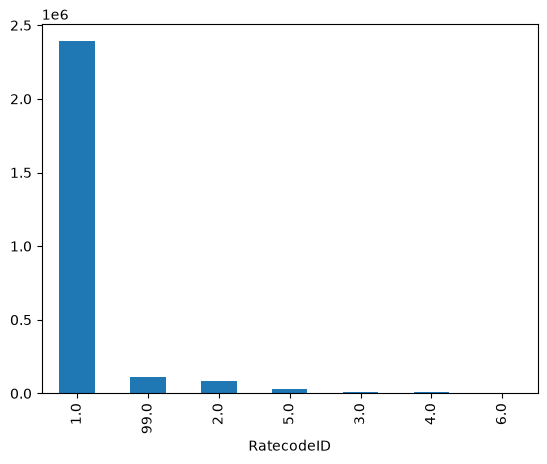

In [28]:
yellow_taxi_jan_2026['RatecodeID'].dropna().value_counts().plot(kind='bar')

-- store_and_fwd_flag

In [29]:
yellow_taxi_jan_2026['store_and_fwd_flag'].value_counts(dropna=False)

store_and_fwd_flag
N      2634494
NaN    1088058
Y         2337
Name: count, dtype: int64

In [30]:
yellow_taxi_jan_2026[yellow_taxi_jan_2026['store_and_fwd_flag'].isna()].sample(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
3100353,2,2026-01-16 15:37:56,2026-01-16 15:57:30,NaN,6.58,NaN,NaN,244,50,0,37.77,0.0,0.5,0.0,0.0,1.0,42.52,NaN,NaN,0.75
2926606,1,2026-01-10 22:08:50,2026-01-10 22:25:53,NaN,2.10,NaN,NaN,186,79,0,17.32,0.0,0.5,0.0,0.0,1.0,23.64,NaN,NaN,0.75
3646316,2,2026-01-30 18:31:45,2026-01-30 18:45:12,NaN,0.00,NaN,NaN,213,184,0,24.19,0.0,0.5,0.0,0.0,1.0,25.69,NaN,NaN,0.00
2876157,2,2026-01-09 19:58:11,2026-01-09 20:13:24,NaN,1.43,NaN,NaN,107,4,0,13.18,0.0,0.5,0.0,0.0,1.0,17.93,NaN,NaN,0.75
3647560,2,2026-01-30 19:19:30,2026-01-30 19:37:41,NaN,0.00,NaN,NaN,262,229,0,16.18,0.0,0.5,0.0,0.0,1.0,20.93,NaN,NaN,0.75
2810618,2,2026-01-07 07:08:09,2026-01-07 07:38:00,NaN,13.96,NaN,NaN,232,241,0,39.18,0.0,0.5,0.0,0.0,1.0,43.93,NaN,NaN,0.75
2881362,2,2026-01-09 22:58:45,2026-01-09 23:07:05,NaN,1.95,NaN,NaN,233,79,0,14.20,0.0,0.5,0.0,0.0,1.0,18.95,NaN,NaN,0.75
3249669,2,2026-01-20 13:04:30,2026-01-20 13:31:36,NaN,3.99,NaN,NaN,141,179,0,22.79,0.0,0.5,0.0,0.0,1.0,27.54,NaN,NaN,0.75
2688353,2,2026-01-02 07:01:33,2026-01-02 07:11:12,NaN,2.44,NaN,NaN,48,246,0,18.18,0.0,0.5,0.0,0.0,1.0,22.93,NaN,NaN,0.75
2902316,2,2026-01-10 14:19:24,2026-01-10 14:40:37,NaN,7.20,NaN,NaN,162,42,0,24.20,0.0,0.5,0.0,0.0,1.0,33.29,NaN,NaN,0.75


-- PULocationID

In [31]:
yellow_taxi_jan_2026['PULocationID'].describe()

count    3.724889e+06
mean     1.614372e+02
std      6.706657e+01
min      1.000000e+00
25%      1.140000e+02
50%      1.610000e+02
75%      2.330000e+02
max      2.650000e+02
Name: PULocationID, dtype: float64

<Axes: ylabel='Frequency'>

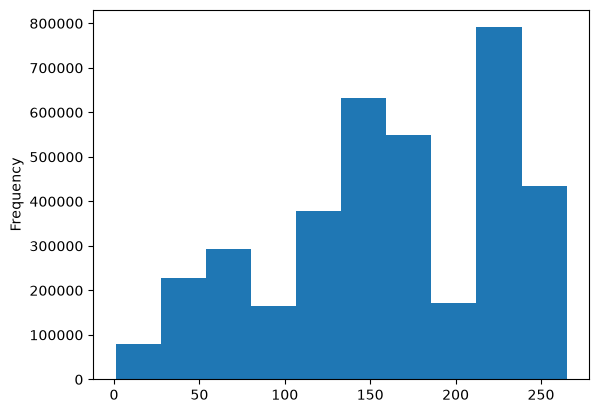

In [32]:
yellow_taxi_jan_2026['PULocationID'].plot(kind='hist')

-- DOLocationID

In [33]:
yellow_taxi_jan_2026['PULocationID'].describe()

count    3.724889e+06
mean     1.614372e+02
std      6.706657e+01
min      1.000000e+00
25%      1.140000e+02
50%      1.610000e+02
75%      2.330000e+02
max      2.650000e+02
Name: PULocationID, dtype: float64

<Axes: ylabel='Frequency'>

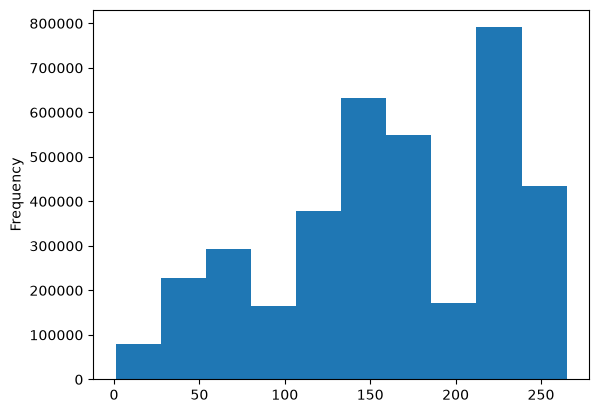

In [34]:
yellow_taxi_jan_2026['PULocationID'].plot(kind='hist')

-- payment_type

In [35]:
yellow_taxi_jan_2026['payment_type'].describe()

count    3.724889e+06
mean     8.465637e-01
std      7.120493e-01
min      0.000000e+00
25%      0.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      4.000000e+00
Name: payment_type, dtype: float64

In [36]:
yellow_taxi_jan_2026['payment_type'].value_counts(dropna=False)

payment_type
1    2249747
0    1088058
2     314043
4      56400
3      16641
Name: count, dtype: int64

-- fare_amount

In [37]:
yellow_taxi_jan_2026['fare_amount'].describe()

count    3.724889e+06
mean     2.080425e+01
std      1.892701e+01
min     -2.555200e+03
25%      1.000000e+01
50%      1.560000e+01
75%      2.610000e+01
max      2.555200e+03
Name: fare_amount, dtype: float64

In [38]:
yellow_taxi_jan_2026[yellow_taxi_jan_2026['fare_amount']<0].sample(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
47157,2,2026-01-01 17:58:50,2026-01-01 18:43:34,1.0,17.91,2.0,N,132,142,4,-70.0,0.0,-0.5,0.0,0.0,-1.0,-76.50,-2.5,-1.75,-0.75
2452513,2,2026-01-30 00:53:37,2026-01-30 01:21:04,1.0,13.42,1.0,N,132,19,4,-51.3,-1.0,-0.5,0.0,0.0,-1.0,-55.55,0.0,-1.75,0.00
792168,2,2026-01-10 17:48:30,2026-01-10 18:10:45,1.0,2.82,1.0,N,75,143,4,-20.5,0.0,-0.5,0.0,0.0,-1.0,-24.50,-2.5,0.00,0.00
2108840,2,2026-01-24 20:14:09,2026-01-24 20:19:08,1.0,0.86,1.0,N,79,107,4,-6.5,-1.0,-0.5,0.0,0.0,-1.0,-12.25,-2.5,0.00,-0.75
192347,2,2026-01-03 17:31:30,2026-01-03 17:57:37,1.0,3.03,1.0,N,163,233,2,-23.3,0.0,-0.5,0.0,0.0,-1.0,-28.05,-2.5,0.00,-0.75
2413324,2,2026-01-29 17:28:28,2026-01-29 17:51:48,1.0,0.88,1.0,N,186,230,4,-19.1,-2.5,-0.5,0.0,0.0,-1.0,-26.35,-2.5,0.00,-0.75
876930,2,2026-01-11 16:31:59,2026-01-11 16:33:06,2.0,0.02,1.0,N,237,237,3,-3.7,0.0,-0.5,0.0,0.0,-1.0,-8.45,-2.5,0.00,-0.75
294193,2,2026-01-05 06:02:18,2026-01-05 06:08:26,1.0,2.19,1.0,N,249,170,4,-10.7,-1.0,-0.5,0.0,0.0,-1.0,-16.45,-2.5,0.00,-0.75
1895797,2,2026-01-22 18:43:44,2026-01-22 18:44:17,1.0,0.00,1.0,N,249,249,4,-3.0,-2.5,-0.5,0.0,0.0,-1.0,-10.25,-2.5,0.00,-0.75
2577447,2,2026-01-31 12:44:46,2026-01-31 12:50:44,1.0,0.49,1.0,N,230,163,4,-7.2,0.0,-0.5,0.0,0.0,-1.0,-11.95,-2.5,0.00,-0.75


-- extra

In [39]:
yellow_taxi_jan_2026['extra'].describe()

count    3.724889e+06
mean     1.023055e+00
std      1.707322e+00
min     -7.500000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      2.500000e+00
max      1.746000e+01
Name: extra, dtype: float64

In [40]:
yellow_taxi_jan_2026[yellow_taxi_jan_2026['extra'] < 0].sample(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
903462,2,2026-01-11 21:38:05,2026-01-11 21:39:12,3.0,0.16,1.0,N,141,141,3,-3.7,-1.0,-0.5,0.0,0.0,-1.0,-8.70,-2.5,0.00,0.00
2408068,2,2026-01-29 17:44:37,2026-01-29 17:50:49,1.0,1.12,1.0,N,50,143,4,-7.9,-2.5,-0.5,0.0,0.0,-1.0,-15.15,-2.5,0.00,-0.75
840904,2,2026-01-11 05:35:19,2026-01-11 05:48:23,2.0,2.39,1.0,N,186,237,4,-15.6,-1.0,-0.5,0.0,0.0,-1.0,-21.35,-2.5,0.00,-0.75
904047,2,2026-01-11 21:06:28,2026-01-11 21:25:20,2.0,11.70,1.0,N,132,265,4,-44.3,-1.0,-0.5,0.0,0.0,-1.0,-48.55,0.0,-1.75,0.00
419118,2,2026-01-06 16:30:44,2026-01-06 16:30:50,2.0,0.00,1.0,N,132,132,4,-3.0,-2.5,-0.5,0.0,0.0,-1.0,-8.75,0.0,-1.75,0.00
2345703,2,2026-01-28 21:48:24,2026-01-28 22:00:12,1.0,5.89,1.0,N,132,28,4,-23.3,-1.0,-0.5,0.0,0.0,-1.0,-27.55,0.0,-1.75,0.00
436665,2,2026-01-06 19:48:55,2026-01-06 20:14:16,1.0,6.42,1.0,N,138,95,4,-32.4,-7.5,-0.5,0.0,0.0,-1.0,-43.15,0.0,-1.75,0.00
219791,2,2026-01-03 23:08:39,2026-01-03 23:15:30,1.0,1.29,1.0,N,68,186,4,-9.3,-1.0,-0.5,0.0,0.0,-1.0,-15.05,-2.5,0.00,-0.75
2558273,2,2026-01-31 05:14:04,2026-01-31 05:19:46,2.0,0.91,1.0,N,164,186,4,-7.2,-1.0,-0.5,0.0,0.0,-1.0,-12.95,-2.5,0.00,-0.75
2181599,2,2026-01-26 22:56:24,2026-01-26 23:24:39,1.0,15.91,1.0,N,132,108,4,-61.1,-1.0,-0.5,0.0,0.0,-1.0,-65.35,0.0,-1.75,0.00


-- mta_tax

In [41]:
yellow_taxi_jan_2026['mta_tax'].describe()

count    3.724889e+06
mean     4.833766e-01
std      1.145558e-01
min     -5.000000e-01
25%      5.000000e-01
50%      5.000000e-01
75%      5.000000e-01
max      4.750000e+00
Name: mta_tax, dtype: float64

<Axes: ylabel='Frequency'>

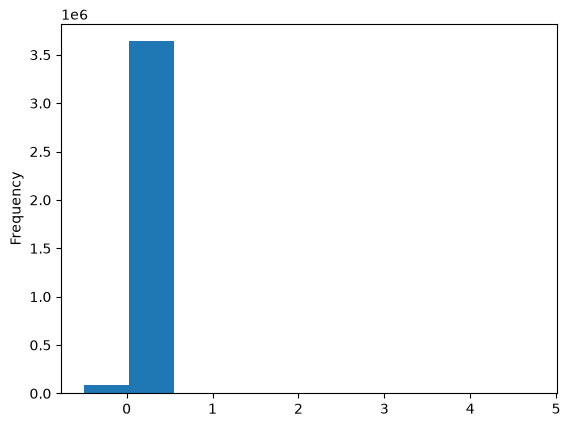

In [42]:
yellow_taxi_jan_2026['mta_tax'].plot(kind='hist')

In [43]:
yellow_taxi_jan_2026[yellow_taxi_jan_2026['mta_tax'] < 0].sample(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
467559,2,2026-01-07 09:35:25,2026-01-07 09:35:35,1.0,0.00,1.0,N,113,113,3,-3.0,0.0,-0.5,0.0,0.0,-1.0,-7.75,-2.5,0.00,-0.75
1728211,2,2026-01-21 01:43:22,2026-01-21 01:48:24,1.0,0.49,1.0,N,162,164,4,-6.5,-1.0,-0.5,0.0,0.0,-1.0,-12.25,-2.5,0.00,-0.75
1413688,2,2026-01-17 09:56:02,2026-01-17 10:06:35,1.0,5.68,1.0,N,170,168,4,-23.3,0.0,-0.5,0.0,0.0,-1.0,-28.05,-2.5,0.00,-0.75
401220,2,2026-01-06 13:18:51,2026-01-06 13:28:09,1.0,1.12,1.0,N,249,234,4,-10.0,0.0,-0.5,0.0,0.0,-1.0,-14.75,-2.5,0.00,-0.75
270397,2,2026-01-04 17:46:37,2026-01-04 17:46:44,1.0,0.01,2.0,N,186,186,4,-70.0,0.0,-0.5,0.0,0.0,-1.0,-74.75,-2.5,0.00,-0.75
1346400,2,2026-01-16 14:43:29,2026-01-16 15:05:23,1.0,10.37,1.0,N,132,155,2,-40.8,0.0,-0.5,0.0,0.0,-1.0,-44.05,0.0,-1.75,0.00
1419513,2,2026-01-17 11:28:39,2026-01-17 11:32:44,2.0,0.73,1.0,N,170,161,4,-5.8,0.0,-0.5,0.0,0.0,-1.0,-10.55,-2.5,0.00,-0.75
2042478,2,2026-01-24 03:27:36,2026-01-24 03:32:15,1.0,0.79,1.0,N,137,137,4,-7.2,-1.0,-0.5,0.0,0.0,-1.0,-12.95,-2.5,0.00,-0.75
267365,2,2026-01-04 17:14:10,2026-01-04 17:44:39,1.0,6.15,1.0,N,163,88,2,-35.2,0.0,-0.5,0.0,0.0,-1.0,-39.95,-2.5,0.00,-0.75
1391401,2,2026-01-16 22:58:40,2026-01-16 23:36:34,1.0,4.46,1.0,N,164,255,4,-35.2,-1.0,-0.5,0.0,0.0,-1.0,-40.95,-2.5,0.00,-0.75


-- tip_amount

In [44]:
yellow_taxi_jan_2026['tip_amount'].describe()

count    3.724889e+06
mean     2.608142e+00
std      3.917405e+00
min     -8.888000e+01
25%      0.000000e+00
50%      2.000000e+00
75%      3.710000e+00
max      7.660000e+02
Name: tip_amount, dtype: float64

In [45]:
yellow_taxi_jan_2026[yellow_taxi_jan_2026['tip_amount'] > 200].sample(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
906758,2,2026-01-11 22:43:24,2026-01-11 22:43:27,1.0,0.00,1.0,N,61,264,1,3.0,1.0,0.5,489.99,0.0,1.0,495.49,0.0,0.0,0.00
2615118,2,2026-01-31 19:12:00,2026-01-31 19:12:08,1.0,0.00,1.0,N,177,264,1,3.0,0.0,0.5,489.00,0.0,1.0,493.50,0.0,0.0,0.00
813653,1,2026-01-10 21:07:51,2026-01-10 21:09:33,1.0,0.00,3.0,N,83,83,1,23.7,1.0,0.0,227.00,97.3,1.0,350.00,0.0,0.0,0.00
407839,2,2026-01-06 15:21:45,2026-01-06 15:42:13,6.0,2.34,1.0,N,142,170,1,18.4,0.0,0.5,355.00,0.0,1.0,378.15,2.5,0.0,0.75
962774,1,2026-01-12 16:34:06,2026-01-12 16:39:11,2.0,0.70,1.0,N,142,142,1,5.8,5.0,0.5,630.45,0.0,1.0,642.75,2.5,0.0,0.00
130176,2,2026-01-02 20:33:05,2026-01-02 20:33:13,1.0,0.00,1.0,N,61,264,1,3.0,1.0,0.5,240.00,0.0,1.0,245.50,0.0,0.0,0.00
2413139,2,2026-01-29 17:56:52,2026-01-29 18:02:56,1.0,0.90,1.0,N,211,231,1,7.9,2.5,0.5,445.45,0.0,1.0,460.60,2.5,0.0,0.75
2585512,1,2026-01-31 14:22:29,2026-01-31 15:01:33,1.0,1.50,1.0,N,78,248,1,31.7,0.0,0.5,766.00,0.0,1.0,799.20,0.0,0.0,0.00
1609187,2,2026-01-19 18:16:21,2026-01-19 18:27:19,6.0,1.76,1.0,N,162,237,1,12.1,0.0,0.5,472.98,0.0,1.0,489.83,2.5,0.0,0.75
793329,2,2026-01-10 17:26:50,2026-01-10 17:26:59,1.0,0.00,1.0,N,61,61,1,3.0,0.0,0.5,350.00,0.0,1.0,354.50,0.0,0.0,0.00


-- tolls_amount

In [46]:
yellow_taxi_jan_2026['tolls_amount'].describe()

count    3.724889e+06
mean     4.983751e-01
std      2.131731e+00
min     -9.450000e+01
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.222200e+02
Name: tolls_amount, dtype: float64

In [47]:
yellow_taxi_jan_2026[yellow_taxi_jan_2026['tolls_amount'] < 0].sample(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
621213,2,2026-01-08 20:18:54,2026-01-08 21:00:30,1.0,26.40,1.0,N,132,18,2,-96.8,-1.0,-0.5,0.0,-7.46,-1.0,-108.51,0.0,-1.75,0.00
1092696,2,2026-01-13 23:25:17,2026-01-13 23:52:51,1.0,18.73,2.0,N,132,74,4,-70.0,0.0,-0.5,0.0,-7.46,-1.0,-83.21,-2.5,-1.75,0.00
1383288,2,2026-01-16 20:58:58,2026-01-16 21:46:25,4.0,17.55,2.0,N,132,68,2,-70.0,0.0,-0.5,0.0,-7.46,-1.0,-83.96,-2.5,-1.75,-0.75
425383,2,2026-01-06 17:26:50,2026-01-06 18:14:06,2.0,18.25,2.0,N,132,163,4,-70.0,-5.0,-0.5,0.0,-6.94,-1.0,-88.44,-2.5,-1.75,-0.75
1150839,2,2026-01-14 16:14:52,2026-01-14 17:01:48,1.0,7.83,1.0,N,261,165,4,-45.0,-2.5,-0.5,0.0,-7.46,-1.0,-59.71,-2.5,0.00,-0.75
1931795,2,2026-01-23 01:21:03,2026-01-23 01:49:59,2.0,17.38,1.0,N,132,213,2,-65.3,-1.0,-0.5,0.0,-7.46,-1.0,-77.01,0.0,-1.75,0.00
778334,2,2026-01-10 15:53:36,2026-01-10 16:23:20,1.0,8.50,1.0,N,230,196,2,-38.7,0.0,-0.5,0.0,-7.46,-1.0,-50.91,-2.5,0.00,-0.75
641812,2,2026-01-09 07:34:59,2026-01-09 08:20:03,1.0,21.33,5.0,N,132,265,4,-163.0,0.0,0.0,0.0,-7.46,-1.0,-173.21,0.0,-1.75,0.00
1094609,2,2026-01-14 02:03:53,2026-01-14 02:55:51,1.0,36.26,4.0,N,132,265,3,-162.6,-1.0,-0.5,0.0,-7.46,-1.0,-172.56,0.0,0.00,0.00
2550993,2,2026-01-31 00:06:37,2026-01-31 00:27:06,1.0,10.28,5.0,N,138,127,4,-67.0,-5.0,0.0,0.0,-7.46,-1.0,-82.21,0.0,-1.75,0.00


-- improvement_surcharge

In [48]:
yellow_taxi_jan_2026['improvement_surcharge'].describe()

count    3.724889e+06
mean     9.479130e-01
std      2.654859e-01
min     -1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: improvement_surcharge, dtype: float64

<Axes: >

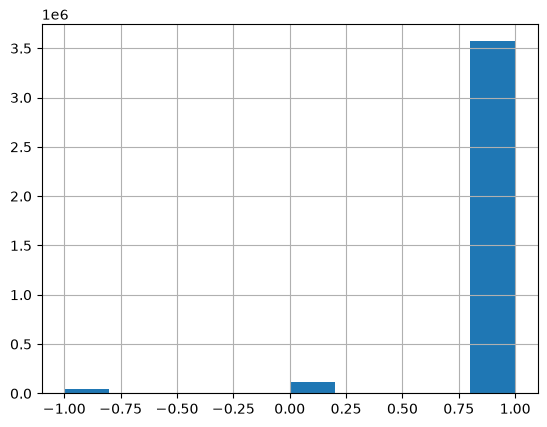

In [49]:
yellow_taxi_jan_2026['improvement_surcharge'].hist()

-- total_amount

In [50]:
yellow_taxi_jan_2026['total_amount'].describe()

count    3.724889e+06
mean     2.917853e+01
std      2.258553e+01
min     -2.560200e+03
25%      1.700000e+01
50%      2.305000e+01
75%      3.383000e+01
max      2.560200e+03
Name: total_amount, dtype: float64

In [51]:
yellow_taxi_jan_2026[yellow_taxi_jan_2026['total_amount']>500].sample(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
2706849,2,2026-01-02 22:04:44,2026-01-02 22:07:32,NaN,0.00,NaN,NaN,244,244,0,680.19,0.00,0.5,0.00,0.00,1.0,684.19,NaN,NaN,0.00
2260818,2,2026-01-27 22:29:13,2026-01-28 12:47:18,1.0,13.58,1.0,N,90,193,4,618.30,1.00,0.5,0.00,7.46,1.0,631.51,2.5,0.00,0.75
2135863,2,2026-01-25 09:37:39,2026-01-25 09:37:45,1.0,0.06,5.0,N,121,98,2,540.00,0.00,0.0,0.00,0.00,1.0,541.00,0.0,0.00,0.00
290297,2,2026-01-05 00:26:18,2026-01-05 00:26:22,2.0,0.00,5.0,N,265,265,3,622.00,0.00,0.0,0.00,0.00,1.0,623.00,0.0,0.00,0.00
896538,2,2026-01-11 19:04:33,2026-01-11 19:04:52,1.0,0.00,5.0,N,101,38,4,502.00,0.00,0.0,0.00,0.00,1.0,503.00,0.0,0.00,0.00
476833,7,2026-01-07 11:52:34,2026-01-07 11:52:34,1.0,107.16,4.0,N,132,265,1,438.40,0.00,0.5,112.15,6.94,1.0,560.74,0.0,1.75,0.00
748528,2,2026-01-10 09:32:11,2026-01-10 11:59:48,1.0,113.99,5.0,N,219,265,2,500.00,0.00,0.0,0.00,0.00,1.0,501.00,0.0,0.00,0.00
498981,2,2026-01-07 15:47:50,2026-01-07 15:47:58,1.0,0.00,5.0,N,138,138,3,500.00,5.00,0.0,0.00,0.00,1.0,507.75,0.0,1.75,0.00
3436400,2,2026-01-25 03:11:04,2026-01-25 04:43:17,NaN,92.76,NaN,NaN,25,265,0,630.55,0.00,0.0,0.00,7.46,1.0,639.01,NaN,NaN,0.00
803335,1,2026-01-10 19:04:48,2026-01-10 23:23:33,1.0,235.50,5.0,N,48,265,1,550.00,0.75,0.0,25.00,0.00,1.0,576.75,0.0,0.00,0.75


-- congestion_surcharge

In [52]:
yellow_taxi_jan_2026['congestion_surcharge'].describe()

count    2.636831e+06
mean     2.154870e+00
std      9.423645e-01
min     -2.500000e+00
25%      2.500000e+00
50%      2.500000e+00
75%      2.500000e+00
max      2.500000e+00
Name: congestion_surcharge, dtype: float64

In [53]:
yellow_taxi_jan_2026[yellow_taxi_jan_2026['congestion_surcharge'] < 0].sample(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
1181360,2,2026-01-14 21:28:48,2026-01-14 21:32:03,1.0,0.45,1.0,N,148,114,4,-5.1,-1.0,-0.5,0.0,0.0,-1.0,-10.85,-2.5,0.00,-0.75
2286505,2,2026-01-28 11:33:59,2026-01-28 11:47:03,1.0,0.64,1.0,N,249,90,4,-12.1,0.0,-0.5,0.0,0.0,-1.0,-16.85,-2.5,0.00,-0.75
161093,2,2026-01-03 11:01:43,2026-01-03 11:12:04,3.0,1.66,1.0,N,230,68,4,-11.4,0.0,-0.5,0.0,0.0,-1.0,-16.15,-2.5,0.00,-0.75
2168269,2,2026-01-26 18:57:03,2026-01-26 19:36:01,1.0,5.73,1.0,N,161,116,4,-33.8,-2.5,-0.5,0.0,0.0,-1.0,-41.05,-2.5,0.00,-0.75
2490384,2,2026-01-30 14:21:57,2026-01-30 14:44:43,1.0,2.05,1.0,N,125,170,2,-19.8,0.0,-0.5,0.0,0.0,-1.0,-24.55,-2.5,0.00,-0.75
1454320,2,2026-01-17 17:41:08,2026-01-17 18:03:29,1.0,0.88,1.0,N,162,230,4,-18.4,0.0,-0.5,0.0,0.0,-1.0,-23.15,-2.5,0.00,-0.75
1268882,2,2026-01-15 18:49:19,2026-01-15 18:55:14,1.0,1.24,1.0,N,186,249,2,-8.6,-2.5,-0.5,0.0,0.0,-1.0,-15.85,-2.5,0.00,-0.75
2252320,2,2026-01-27 20:18:20,2026-01-27 21:03:33,1.0,16.91,1.0,N,132,141,4,-28.2,-1.0,-0.5,0.0,0.0,-1.0,-34.95,-2.5,-1.75,0.00
636251,2,2026-01-09 00:40:28,2026-01-09 00:48:22,1.0,2.02,1.0,N,79,162,2,-10.7,-1.0,-0.5,0.0,0.0,-1.0,-16.45,-2.5,0.00,-0.75
1385590,2,2026-01-16 21:47:21,2026-01-16 21:54:35,1.0,0.99,1.0,N,236,75,4,-8.6,-1.0,-0.5,0.0,0.0,-1.0,-13.60,-2.5,0.00,0.00


-- Airport_fee

In [54]:
yellow_taxi_jan_2026['Airport_fee'].describe()

count    2.636831e+06
mean     1.482938e-01
std      5.336714e-01
min     -1.750000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.675000e+01
Name: Airport_fee, dtype: float64

<Axes: ylabel='Frequency'>

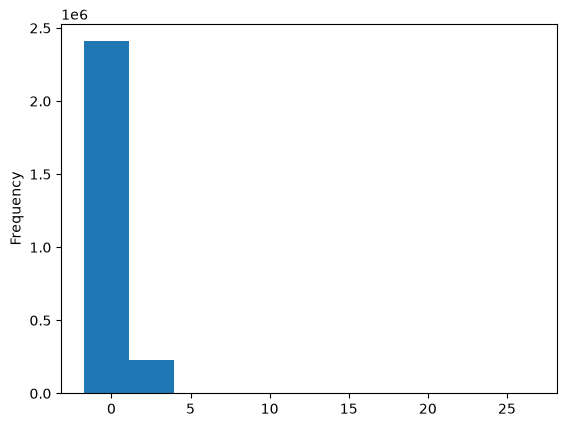

In [59]:
yellow_taxi_jan_2026['Airport_fee'].plot(kind='hist')

In [60]:
yellow_taxi_jan_2026['Airport_fee'].value_counts()

Airport_fee
 0.00     2399229
 1.75      226970
-1.75        9225
 6.75        1034
 5.00         301
 20.00         62
 26.75          6
 21.75          4
Name: count, dtype: int64

In [55]:
yellow_taxi_jan_2026[yellow_taxi_jan_2026['Airport_fee'] < 0 ].sample(15)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
1624913,2,2026-01-19 21:30:06,2026-01-19 22:13:17,1.0,19.53,2.0,N,132,238,2,-70.0,0.0,-0.5,0.0,-7.46,-1.0,-83.21,-2.5,-1.75,0.00
2195909,2,2026-01-27 09:24:41,2026-01-27 10:40:38,1.0,18.63,3.0,N,132,234,4,-107.0,0.0,0.0,0.0,-7.46,-1.0,-117.96,0.0,-1.75,-0.75
1024407,2,2026-01-13 11:07:57,2026-01-13 11:24:13,3.0,8.61,1.0,N,138,119,4,-33.8,-5.0,-0.5,0.0,-7.46,-1.0,-49.51,0.0,-1.75,0.00
1453916,2,2026-01-17 17:07:22,2026-01-17 17:50:00,1.0,18.99,2.0,N,132,114,4,-70.0,0.0,-0.5,0.0,-7.46,-1.0,-83.96,-2.5,-1.75,-0.75
2351140,2,2026-01-28 22:52:21,2026-01-28 23:21:48,1.0,16.41,2.0,N,132,170,2,-70.0,0.0,-0.5,0.0,-7.46,-1.0,-83.96,-2.5,-1.75,-0.75
724910,2,2026-01-09 22:40:39,2026-01-09 23:03:04,1.0,10.38,1.0,N,132,72,4,-41.5,-1.0,-0.5,0.0,0.00,-1.0,-48.25,-2.5,-1.75,0.00
1359139,2,2026-01-16 16:42:03,2026-01-16 17:16:39,3.0,8.77,1.0,N,138,161,3,-42.2,-7.5,-0.5,0.0,-7.46,-1.0,-63.66,-2.5,-1.75,-0.75
793892,2,2026-01-10 17:17:58,2026-01-10 17:19:19,1.0,0.02,1.0,N,132,132,3,-3.7,0.0,-0.5,0.0,0.00,-1.0,-6.95,0.0,-1.75,0.00
1556476,2,2026-01-18 22:17:30,2026-01-18 22:30:48,1.0,7.27,1.0,N,132,93,2,-28.2,-1.0,-0.5,0.0,0.00,-1.0,-32.45,0.0,-1.75,0.00
1278058,2,2026-01-15 19:46:13,2026-01-15 20:27:02,1.0,20.11,1.0,N,132,47,2,-75.8,-2.5,-0.5,0.0,-7.46,-1.0,-89.01,0.0,-1.75,0.00


-- cbd_congestion_fee

In [56]:
yellow_taxi_jan_2026['cbd_congestion_fee'].describe()

count    3.724889e+06
mean     5.196437e-01
std      3.568099e-01
min     -7.500000e-01
25%      0.000000e+00
50%      7.500000e-01
75%      7.500000e-01
max      7.500000e-01
Name: cbd_congestion_fee, dtype: float64

In [61]:
yellow_taxi_jan_2026['cbd_congestion_fee'].value_counts()

cbd_congestion_fee
 0.75    2606017
 0.00    1093675
-0.75      25197
Name: count, dtype: int64

In [57]:
yellow_taxi_jan_2026[yellow_taxi_jan_2026['cbd_congestion_fee'] < 0].sample(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
2431577,2,2026-01-29 20:21:02,2026-01-29 20:28:22,1.0,1.44,1.0,N,48,142,4,-10.0,-1.0,-0.5,0.0,0.00,-1.0,-15.75,-2.5,0.00,-0.75
2481985,2,2026-01-30 12:00:46,2026-01-30 12:53:13,1.0,13.40,1.0,N,138,68,4,-66.7,-5.0,-0.5,0.0,-7.46,-1.0,-85.66,-2.5,-1.75,-0.75
694518,2,2026-01-09 17:29:19,2026-01-09 17:52:36,1.0,1.90,1.0,N,107,230,4,-19.8,-2.5,-0.5,0.0,0.00,-1.0,-27.05,-2.5,0.00,-0.75
88886,2,2026-01-02 12:46:13,2026-01-02 13:05:37,1.0,2.95,1.0,N,186,148,4,-19.8,0.0,-0.5,0.0,0.00,-1.0,-24.55,-2.5,0.00,-0.75
1035836,2,2026-01-13 13:46:25,2026-01-13 14:15:06,2.0,4.08,1.0,N,144,236,2,-26.8,0.0,-0.5,0.0,0.00,-1.0,-31.55,-2.5,0.00,-0.75
2430565,2,2026-01-29 20:59:19,2026-01-29 20:59:33,1.0,0.00,1.0,N,144,144,4,-3.0,-1.0,-0.5,0.0,0.00,-1.0,-8.75,-2.5,0.00,-0.75
2215630,2,2026-01-27 14:10:59,2026-01-27 14:17:15,1.0,0.72,1.0,N,48,142,2,0.0,0.0,-0.5,0.0,0.00,-1.0,-4.75,-2.5,0.00,-0.75
1687323,2,2026-01-20 16:56:29,2026-01-20 17:17:49,1.0,2.42,1.0,N,162,236,4,-19.8,-2.5,-0.5,0.0,0.00,-1.0,-27.05,-2.5,0.00,-0.75
1842382,2,2026-01-22 09:32:49,2026-01-22 09:39:30,2.0,1.07,1.0,N,249,249,4,-8.6,0.0,-0.5,0.0,0.00,-1.0,-13.35,-2.5,0.00,-0.75
129851,2,2026-01-02 20:18:13,2026-01-02 20:24:47,1.0,0.92,1.0,N,163,48,2,-7.9,-1.0,-0.5,0.0,0.00,-1.0,-13.65,-2.5,0.00,-0.75


In [58]:
yellow_taxi_jan_2026.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee',
       'cbd_congestion_fee'],
      dtype='str')